### the imputation step:  Missing Value Imputation

Implements and compares two time-series-appropriate imputation strategies on the cleaned dataset:

| Method | Description |
|--------|-------------|
| **A** | Forward-fill (LOCF) with maximum gap limit |
| **B** | Linear interpolation with maximum gap limit |

Both methods respect the temporal structure of the data and apply a hard gap limit  
so that prolonged missing periods are never imputed.  
The comparison selects one method and exports `data_imputed.csv` for the feature engineering step.

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats

# ── Config ────────────────────────────────────────────────────────────────
CLEAN_PATH  = "../outputs/data_cleaned.csv"          # from eda_outliers.ipynb
DAILY_PATH  = "../outputs/daily_aggregated.csv"      # from eda_daily_aggregation.ipynb
ID_COL      = "id"
DATE_COL    = "date"
TIME_COL    = "time"
VAR_COL     = "variable"
VAL_COL     = "value"

# Maximum consecutive missing days to impute.
# Days in gaps longer than this are left as NaN.
# Justified by ACF analysis (b_10): mood lag-1 autocorrelation is 0.472 and
# drops to ~0.30 by lag-3, then plateaus through lag-6 before declining further.
# Imputing beyond 3 days would rely on increasingly weak temporal structure.
# A conservative limit of 3 keeps imputed values within the strongest
# autocorrelation range.  See also: Little & Rubin (2002), ch. 11.
MAX_GAP     = 3

# Variables excluded from imputation:
#
# call / sms: The EAV format only logs events (value=1 when they occur);
# absence of a record means no call/SMS was made, not that the value is
# missing.  Filling with 0 encodes the recording convention, it is not
# imputation.  This is why zero_% = 0% but zero_days_% is substantial
# for both variables (see b_02).
NO_IMPUTE   = ["call", "sms"]

# Structurally sparse variables (>70% missing globally, per b_05
# missingness classification).  These are filled with 0 because absence
# means no usage, not a gap to interpolate.  100% missing patient-variable
# combos (e.g. appCat.weather for 15/27 patients) stay as 0, which is the
# correct representation — imputing nonzero values would fabricate data.
STRUCTURAL_SPARSE = [
    "appCat.finance", "appCat.weather", "appCat.travel",
    "appCat.game",    "appCat.office",
]

# Variables to track closely in the comparison
FOCUS_VARS  = [
    "mood", "circumplex.valence", "circumplex.arousal",
    "activity", "screen", "appCat.social", "appCat.communication",
]

In [24]:
raw_clean = pd.read_csv(CLEAN_PATH)
raw_clean[TIME_COL] = pd.to_datetime(raw_clean[TIME_COL], format='mixed', dayfirst=True)
raw_clean["date"]  = raw_clean[TIME_COL].dt.normalize()
raw_clean[VAL_COL] = pd.to_numeric(raw_clean[VAL_COL], errors="coerce")

patients  = sorted(raw_clean[ID_COL].unique())
all_vars  = sorted(raw_clean[VAR_COL].unique())
print(f"Patients: {len(patients)}  |  Variables: {len(all_vars)}  |  Records: {len(raw_clean):,}")

Patients: 27  |  Variables: 19  |  Records: 355,592


#### 1. Build the patient-day panel
Pivot to (patient × day × variable) wide format.  
Fill structural sparse variables with 0 before imputation.

In [25]:
# Daily mean for rated variables, daily sum for duration/count variables
MEAN_VARS = ["mood", "circumplex.arousal", "circumplex.valence", "activity"]
SUM_VARS  = [v for v in all_vars if v not in MEAN_VARS]

mean_piv = (
    raw_clean[raw_clean[VAR_COL].isin(MEAN_VARS)]
    .groupby([ID_COL, "date", VAR_COL])[VAL_COL].mean()
    .unstack(VAR_COL)
)
sum_piv = (
    raw_clean[raw_clean[VAR_COL].isin(SUM_VARS)]
    .groupby([ID_COL, "date", VAR_COL])[VAL_COL].sum(min_count=1)
    .unstack(VAR_COL)
)

panel = mean_piv.join(sum_piv, how="outer").reset_index()

# Expand to full calendar range per patient so gaps become explicit NaN rows
expanded = []
for patient, grp in panel.groupby(ID_COL):
    full_dates = pd.date_range(grp["date"].min(), grp["date"].max(), freq="D")
    grp = grp.set_index("date").reindex(full_dates)
    grp[ID_COL] = patient
    grp.index.name = "date"
    expanded.append(grp.reset_index())

panel = pd.concat(expanded, ignore_index=True)
panel = panel.sort_values([ID_COL, "date"]).reset_index(drop=True)

# Fill structural sparse variables with 0 — absence = no usage, not missing
for v in STRUCTURAL_SPARSE:
    if v in panel.columns:
        panel[v] = panel[v].fillna(0)
for v in NO_IMPUTE:
    if v in panel.columns:
        panel[v] = panel[v].fillna(0)

feat_cols = [c for c in panel.columns if c not in [ID_COL, "date"]]
n_missing_before = panel[feat_cols].isna().sum().sum()
print(f"Patient-days in panel : {len(panel):,}")
print(f"Missing cells (before): {n_missing_before:,}")

# ── Sanity check: no negative durations should survive from b_06 cleaning ─
duration_cols = [c for c in feat_cols if c.startswith("appCat.") or c == "screen"]
neg_count = (panel[duration_cols] < 0).sum().sum()
assert neg_count == 0, f"Found {neg_count} negative duration values — check data_cleaned.csv"
print(f"Sanity check passed: 0 negative durations in panel")

Patient-days in panel : 9,069
Missing cells (before): 96,700
Sanity check passed: 0 negative durations in panel


#### 1b. Validate structural sparse classification

Cross-check that the variables in `STRUCTURAL_SPARSE` match the >70% global missingness threshold from b_05.

In [26]:
# Compute global missingness per variable in the raw panel (before filling)
# Re-derive from raw_clean to avoid using the already-filled panel
raw_daily = mean_piv.join(sum_piv, how="outer").reset_index()
exp2 = []
for patient, grp in raw_daily.groupby(ID_COL):
    full_dates = pd.date_range(grp["date"].min(), grp["date"].max(), freq="D")
    grp = grp.set_index("date").reindex(full_dates)
    grp[ID_COL] = patient
    grp.index.name = "date"
    exp2.append(grp.reset_index())
raw_panel = pd.concat(exp2, ignore_index=True)

raw_feat = [c for c in raw_panel.columns if c not in [ID_COL, "date"]]
miss_pct = (raw_panel[raw_feat].isna().sum() / len(raw_panel) * 100).sort_values(ascending=False)

STRUCTURAL_PCT = 70
classified_sparse = miss_pct[miss_pct > STRUCTURAL_PCT].index.tolist()

print(f"Variables with >{STRUCTURAL_PCT}% global missingness:")
for v in classified_sparse:
    tag = "✓ in list" if v in STRUCTURAL_SPARSE else "⚠ NOT in STRUCTURAL_SPARSE"
    print(f"  {v:30s} {miss_pct[v]:5.1f}%  {tag}")

extra_in_list = set(STRUCTURAL_SPARSE) - set(classified_sparse)
if extra_in_list:
    print(f"\n⚠ Variables in STRUCTURAL_SPARSE but below {STRUCTURAL_PCT}% threshold:")
    for v in extra_in_list:
        print(f"  {v:30s} {miss_pct.get(v, 0):5.1f}%")
else:
    print(f"\n✓ All STRUCTURAL_SPARSE entries confirmed above {STRUCTURAL_PCT}% threshold.")

del raw_daily, exp2, raw_panel  # free memory

Variables with >70% global missingness:
  appCat.weather                  98.8%  ✓ in list
  appCat.game                     98.0%  ✓ in list
  appCat.finance                  97.8%  ✓ in list
  appCat.office                   97.5%  ✓ in list
  appCat.unknown                  97.2%  ⚠ NOT in STRUCTURAL_SPARSE
  appCat.travel                   95.3%  ✓ in list
  appCat.utilities                95.3%  ⚠ NOT in STRUCTURAL_SPARSE
  sms                             91.9%  ⚠ NOT in STRUCTURAL_SPARSE
  appCat.entertainment            91.4%  ⚠ NOT in STRUCTURAL_SPARSE
  appCat.social                   89.2%  ⚠ NOT in STRUCTURAL_SPARSE
  appCat.other                    87.7%  ⚠ NOT in STRUCTURAL_SPARSE
  appCat.communication            87.0%  ⚠ NOT in STRUCTURAL_SPARSE
  activity                        86.9%  ⚠ NOT in STRUCTURAL_SPARSE
  appCat.builtin                  86.8%  ⚠ NOT in STRUCTURAL_SPARSE
  screen                          86.7%  ⚠ NOT in STRUCTURAL_SPARSE
  circumplex.valence     

#### 2. Imputation functions

In [27]:
def gap_mask(series: pd.Series, max_gap: int) -> pd.Series:
    """
    Returns a boolean mask marking positions that belong to a consecutive
    NaN run longer than max_gap days.  These positions must stay NaN.

    Note: leading NaN runs (before any observed value) are also protected
    if they exceed max_gap.  This is safe because neither ffill nor linear
    interpolation can fill leading NaNs anyway (no anchor point).
    """
    is_nan   = series.isna()
    block_id = (~is_nan).cumsum()
    # Count run length for each NaN block
    run_len  = is_nan.groupby(block_id).transform("sum")
    return is_nan & (run_len > max_gap)


def impute_ffill(series: pd.Series, max_gap: int) -> pd.Series:
    """Forward-fill (LOCF) limited to max_gap consecutive days."""
    protected = gap_mask(series, max_gap)    # positions that must stay NaN
    filled    = series.ffill(limit=max_gap)
    filled[protected] = np.nan
    return filled


def impute_linear(series: pd.Series, max_gap: int) -> pd.Series:
    """Linear interpolation limited to max_gap consecutive days."""
    protected = gap_mask(series, max_gap)
    filled    = series.interpolate(method="linear", limit=max_gap,
                                   limit_direction="forward")
    filled[protected] = np.nan
    return filled


def apply_imputation(panel: pd.DataFrame,
                     method: str,
                     max_gap: int,
                     skip_cols: list) -> pd.DataFrame:
    """
    Apply chosen imputation method per patient per variable.
    method: 'ffill' or 'linear'
    """
    result = panel.copy()
    imp_fn = impute_ffill if method == "ffill" else impute_linear

    for col in feat_cols:
        if col in skip_cols:
            continue
        result[col] = (
            result.groupby(ID_COL)[col]
                  .transform(lambda s: imp_fn(s, max_gap))
        )
    return result


skip = STRUCTURAL_SPARSE + NO_IMPUTE   # already handled
print("Functions defined. Applying both methods...")

Functions defined. Applying both methods...


In [28]:
panel_ffill  = apply_imputation(panel, "ffill",  MAX_GAP, skip)
panel_linear = apply_imputation(panel, "linear", MAX_GAP, skip)

n_after_ff = panel_ffill[feat_cols].isna().sum().sum()
n_after_li = panel_linear[feat_cols].isna().sum().sum()

print(f"Missing cells after forward-fill : {n_after_ff:,}  "
      f"(filled {n_missing_before - n_after_ff:,} cells)")
print(f"Missing cells after interpolation: {n_after_li:,}  "
      f"(filled {n_missing_before - n_after_li:,} cells)")

Missing cells after forward-fill : 95,194  (filled 1,506 cells)
Missing cells after interpolation: 95,194  (filled 1,506 cells)


#### 3. Comparison - distributional fidelity
Good imputation should not shift the mean, inflate variance, or destroy autocorrelation.  
Compare observed vs imputed distributions for focus variables.

In [29]:
focus = [v for v in FOCUS_VARS if v in panel.columns]
comp_rows = []

for var in focus:
    observed = panel[var].dropna()
    ff_vals  = panel_ffill[var]
    li_vals  = panel_linear[var]

    # Values that were imputed (NaN in original, non-NaN after imputation)
    imputed_mask = panel[var].isna()
    ff_imputed   = ff_vals[imputed_mask].dropna()
    li_imputed   = li_vals[imputed_mask].dropna()

    def safe_skew(s):
        s = s.dropna()
        return round(float(stats.skew(s)), 3) if len(s) > 2 and s.std() > 1e-10 else np.nan
    
    # KS test: compare full post-imputation distribution vs observed
    # Small D-statistic and large p-value = imputation preserved the distribution
    ks_ff = stats.ks_2samp(observed, ff_vals.dropna()) if len(ff_vals.dropna()) > 2 else (np.nan, np.nan)
    ks_li = stats.ks_2samp(observed, li_vals.dropna()) if len(li_vals.dropna()) > 2 else (np.nan, np.nan)

    comp_rows.append({
        "variable":           var,
        # Observed
        "obs_mean":           round(observed.mean(), 3),
        "obs_std":            round(observed.std(),  3),
        "obs_skew":           safe_skew(observed),
        # Forward-fill imputed values only
        "ff_imputed_mean":    round(ff_imputed.mean(),  3) if len(ff_imputed) else np.nan,
        "ff_imputed_std":     round(ff_imputed.std(),   3) if len(ff_imputed) else np.nan,
        "ff_imputed_skew":    safe_skew(ff_imputed),
        "ff_ks_D":            round(ks_ff.statistic, 4) if hasattr(ks_ff, 'statistic') else round(ks_ff[0], 4),
        "ff_ks_p":            round(ks_ff.pvalue, 4) if hasattr(ks_ff, 'pvalue') else round(ks_ff[1], 4),
        # Linear imputed values only
        "li_imputed_mean":    round(li_imputed.mean(),  3) if len(li_imputed) else np.nan,
        "li_imputed_std":     round(li_imputed.std(),   3) if len(li_imputed) else np.nan,
        "li_imputed_skew":    safe_skew(li_imputed),
        "li_ks_D":            round(ks_li.statistic, 4) if hasattr(ks_li, 'statistic') else round(ks_li[0], 4),
        "li_ks_p":            round(ks_li.pvalue, 4) if hasattr(ks_li, 'pvalue') else round(ks_li[1], 4),
        "n_imputed_ff":       len(ff_imputed),
        "n_imputed_li":       len(li_imputed),
    })

comp_df = pd.DataFrame(comp_rows).set_index("variable")
pd.set_option("display.float_format", "{:.3f}".format)
print("Distributional comparison - observed vs imputed values:")
comp_df
print("(KS D = max distance between CDFs; small D + large p = distribution preserved)")
comp_df

Distributional comparison - observed vs imputed values:
(KS D = max distance between CDFs; small D + large p = distribution preserved)


,obs_mean,obs_std,obs_skew,ff_imputed_mean,ff_imputed_std,ff_imputed_skew,ff_ks_D,ff_ks_p,li_imputed_mean,li_imputed_std,li_imputed_skew,li_ks_D,li_ks_p,n_imputed_ff,n_imputed_li
variable,,,,,,,,,,,,,,,
mood,6.990,0.736,-0.800,6.954,0.747,-0.881,0.009,1.000,7.051,0.568,-1.011,0.018,0.982,133,133
circumplex.valence,0.687,0.435,-0.813,0.673,0.382,-0.588,0.007,1.000,0.719,0.333,-0.285,0.009,1.000,133,133
circumplex.arousal,-0.104,0.663,-0.125,-0.191,0.714,-0.046,0.010,1.000,-0.099,0.607,-0.021,0.008,1.000,133,133
activity,0.120,0.098,1.572,0.123,0.111,1.802,0.007,1.000,0.131,0.099,1.852,0.011,1.000,125,125
screen,2774.728,1924.155,0.776,2603.931,2020.528,0.693,0.010,1.000,2593.565,1704.704,0.349,0.007,1.000,129,129
appCat.social,882.053,967.798,2.023,536.775,529.420,0.891,0.019,0.987,580.355,599.632,1.094,0.020,0.979,123,123
appCat.communication,1722.439,1434.027,1.272,1673.671,1493.058,0.934,0.009,1.000,1604.246,1294.228,0.942,0.008,1.000,131,131


#### 4. Comparison - autocorrelation preservation
Imputation that destroys the autocorrelation of mood would corrupt the prediction task.

In [30]:
def pooled_lag1_acf(panel_df: pd.DataFrame, col: str) -> float:
    """
    Lag-1 Pearson autocorrelation of col, computed within patient then averaged.

    Only pairs of *consecutive calendar days* (date difference = 1 day) are
    included.  After imputation, prolonged gaps leave NaN blocks; dropping NaN
    and pairing adjacent rows would incorrectly treat e.g. day-5 → day-12 as
    a lag-1 pair.  This filter prevents that.
    """
    rs = []
    for _, grp in panel_df.groupby(ID_COL):
        grp = grp.sort_values("date")
        vals = grp[[col, "date"]].copy()
        vals["next_val"]  = vals[col].shift(-1)
        vals["next_date"] = vals["date"].shift(-1)
        # Keep only consecutive calendar days where both values are non-NaN
        consec = vals[
            (vals["next_date"] - vals["date"]) == pd.Timedelta(days=1)
        ].dropna(subset=[col, "next_val"])
        if len(consec) < 4:
            continue
        r, _ = stats.pearsonr(consec[col].values, consec["next_val"].values)
        rs.append(r)
    return round(float(np.mean(rs)), 4) if rs else np.nan


acf_rows = []
for var in focus:
    acf_rows.append({
        "variable":  var,
        "ACF_observed": pooled_lag1_acf(panel,        var),
        "ACF_ffill":    pooled_lag1_acf(panel_ffill,  var),
        "ACF_linear":   pooled_lag1_acf(panel_linear, var),
    })

acf_df = pd.DataFrame(acf_rows).set_index("variable")
acf_df["ffill_delta"]  = (acf_df["ACF_ffill"]  - acf_df["ACF_observed"]).round(4)
acf_df["linear_delta"] = (acf_df["ACF_linear"] - acf_df["ACF_observed"]).round(4)

print("Lag-1 autocorrelation before and after imputation:")
print("(delta = change from observed; positive = inflated autocorrelation)")
print("(only consecutive calendar day pairs are used)")
acf_df

Lag-1 autocorrelation before and after imputation:
(delta = change from observed; positive = inflated autocorrelation)
(only consecutive calendar day pairs are used)


,ACF_observed,ACF_ffill,ACF_linear,ffill_delta,linear_delta
variable,,,,,
mood,0.227,0.277,0.286,0.050,0.059
circumplex.valence,0.138,0.204,0.221,0.066,0.083
circumplex.arousal,0.119,0.194,0.210,0.075,0.091
activity,0.018,0.062,0.085,0.044,0.068
screen,0.197,0.267,0.281,0.070,0.084
appCat.social,0.116,0.190,0.212,0.074,0.096
appCat.communication,0.234,0.295,0.322,0.061,0.088


#### 5. Comparison - visual inspection for mood

In [31]:
# Pick patient with most successfully imputed mood days (not just missing days)
imputed_mask = panel["mood"].isna()

n_imputed_per_patient = (
    panel_linear[imputed_mask]
    .groupby(ID_COL)["mood"]
    .apply(lambda s: s.notna().sum())
    .sort_values(ascending=False)
)

if n_imputed_per_patient.max() == 0:
    print("No patient has any imputed mood values — all gaps exceed MAX_GAP.")
    print("Consider temporarily raising MAX_GAP to verify imputation works.")
else:
    inspect_patient = n_imputed_per_patient.index[0]
    print(f"Inspecting patient: {inspect_patient}  "
          f"({n_imputed_per_patient.iloc[0]} successfully imputed mood days)")

Inspecting patient: AS14.14  (8 successfully imputed mood days)


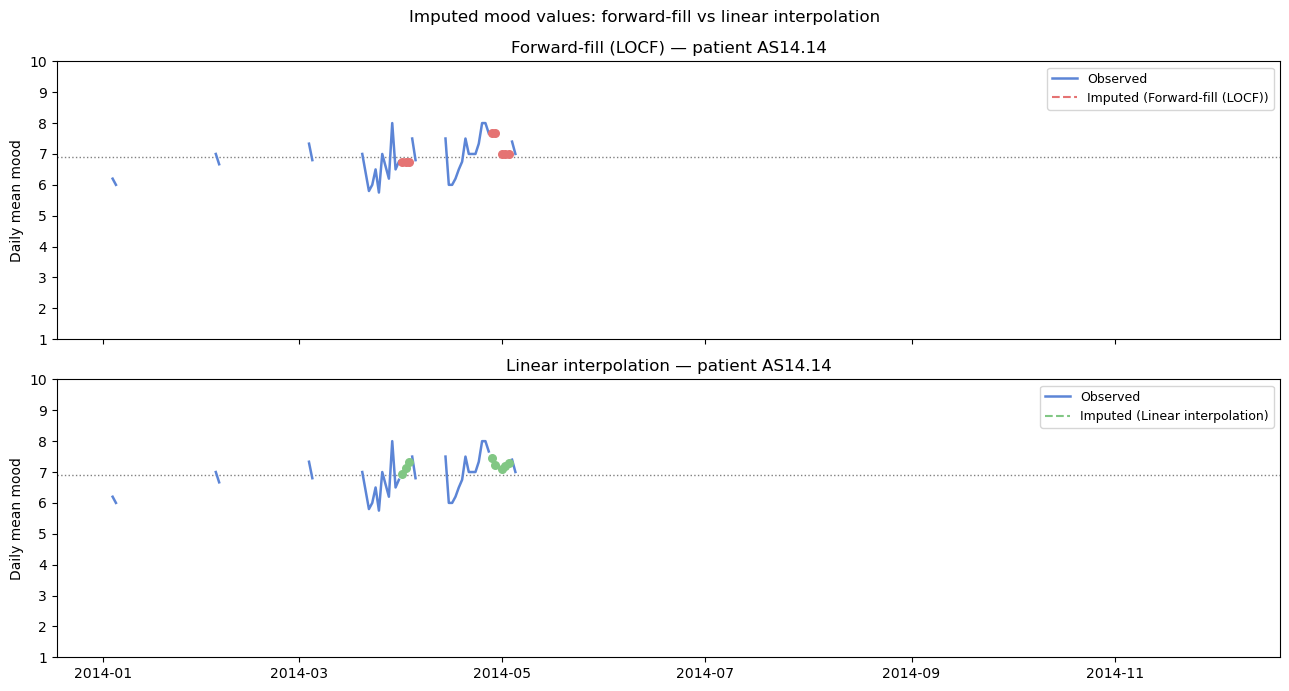

In [32]:
orig = panel[panel[ID_COL] == inspect_patient].set_index("date")["mood"]
ff   = panel_ffill[panel_ffill[ID_COL] == inspect_patient].set_index("date")["mood"]
li   = panel_linear[panel_linear[ID_COL] == inspect_patient].set_index("date")["mood"]
imputed_days = orig[orig.isna()].index

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

for ax, imp_vals, method_name, color in [
    (axes[0], ff, "Forward-fill (LOCF)",      "#e57373"),
    (axes[1], li, "Linear interpolation",      "#81c784"),
]:
    # Observed values
    ax.plot(orig.index, orig.values,
            color="#5c85d6", linewidth=1.8, label="Observed", zorder=3)
    # Imputed values highlighted
    imp_only = imp_vals.copy()
    imp_only[~orig.isna()] = np.nan
    ax.plot(imp_only.index, imp_only.values,
            color=color, linewidth=1.5, linestyle="--",
            label=f"Imputed ({method_name})", zorder=2)
    ax.scatter(imp_only.dropna().index, imp_only.dropna().values,
               color=color, s=30, zorder=4)

    ax.set_ylim(1, 10)
    ax.set_ylabel("Daily mean mood")
    ax.set_title(f"{method_name} — patient {inspect_patient}")
    ax.legend(fontsize=9)
    ax.axhline(orig.mean(), color="grey", linestyle=":",
               linewidth=1, label="Patient mean")

plt.suptitle("Imputed mood values: forward-fill vs linear interpolation",
             fontsize=12)
plt.tight_layout()
plt.savefig("../figures/imputation_mood_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

Documents how many days remain as NaN after imputation and why.

In [33]:
gap_rows = []
for var in focus:
    total_days    = panel[var].isna().sum()
    filled_ff     = total_days - panel_ffill[var].isna().sum()
    filled_li     = total_days - panel_linear[var].isna().sum()
    prolonged_ff  = panel_ffill[var].isna().sum()
    prolonged_li  = panel_linear[var].isna().sum()
    gap_rows.append({
        "variable":           var,
        "total_missing_days": int(total_days),
        "filled_ffill":       int(filled_ff),
        "filled_linear":      int(filled_li),
        "remain_NaN_ffill":   int(prolonged_ff),
        "remain_NaN_linear":  int(prolonged_li),
    })

gap_df = pd.DataFrame(gap_rows).set_index("variable")
print(f"Gap limit applied: {MAX_GAP} days")
print("Days remaining as NaN (in prolonged gaps, not imputed):")
gap_df

Gap limit applied: 3 days
Days remaining as NaN (in prolonged gaps, not imputed):


,total_missing_days,filled_ffill,filled_linear,remain_NaN_ffill,remain_NaN_linear
variable,,,,,
mood,7801,133,133,7668,7668
circumplex.valence,7803,133,133,7670,7670
circumplex.arousal,7801,133,133,7668,7668
activity,7881,125,125,7756,7756
screen,7864,129,129,7735,7735
appCat.social,8089,123,123,7966,7966
appCat.communication,7887,131,131,7756,7756


In [34]:

print("─" * 60)
print("Downstream handling (Task 1C):")
print(f"  Remaining NaN values are left intentionally.  In Task 1C,")
print(f"  any sliding-window instance that overlaps a remaining NaN")
print(f"  will be excluded from the training set.  This is preferred")
print(f"  over fabricating values for gaps longer than {MAX_GAP} days,")
print(f"  where the temporal signal is too weak to support imputation.")
print(f"  Patients AS14.33 (58-day mood streak) and AS14.25 (50-day")
print(f"  streak) will lose the most training instances as a result.")

────────────────────────────────────────────────────────────
Downstream handling (Task 1C):
  Remaining NaN values are left intentionally.  In Task 1C,
  any sliding-window instance that overlaps a remaining NaN
  will be excluded from the training set.  This is preferred
  over fabricating values for gaps longer than 3 days,
  where the temporal signal is too weak to support imputation.
  Patients AS14.33 (58-day mood streak) and AS14.25 (50-day
  streak) will lose the most training instances as a result.


#### 6b. Per-patient imputation impact
Shows how many cells each patient gained from imputation, highlighting the most and least affected patients.

In [35]:
# Per-patient: cells missing before vs after imputation (using chosen method later,
# but for comparison we show linear here since it's the default)
patient_impact = []
for patient in patients:
    mask = panel[ID_COL] == patient
    before = panel.loc[mask, feat_cols].isna().sum().sum()
    after  = panel_linear.loc[mask, feat_cols].isna().sum().sum()
    patient_impact.append({
        "patient": patient,
        "missing_before": int(before),
        "missing_after_linear": int(after),
        "cells_filled": int(before - after),
        "fill_rate_%": round((before - after) / before * 100, 1) if before > 0 else 0.0,
    })

patient_df = pd.DataFrame(patient_impact).set_index("patient")
patient_df = patient_df.sort_values("cells_filled", ascending=False)

print("Per-patient imputation impact (linear interpolation):")
print(f"  Most cells filled : {patient_df.index[0]} ({patient_df.iloc[0]['cells_filled']} cells)")
print(f"  Least cells filled: {patient_df.index[-1]} ({patient_df.iloc[-1]['cells_filled']} cells)")
print()
patient_df

Per-patient imputation impact (linear interpolation):
  Most cells filled : AS14.16 (88.0 cells)
  Least cells filled: AS14.25 (2.0 cells)



,missing_before,missing_after_linear,cells_filled,fill_rate_%
patient,,,,
AS14.16,3585,3497,88,2.500
AS14.28,3597,3512,85,2.400
AS14.30,3483,3404,79,2.300
AS14.23,3570,3493,77,2.200
AS14.08,3454,3380,74,2.100
AS14.07,3539,3465,74,2.100
AS14.03,3548,3475,73,2.100
AS14.05,3448,3375,73,2.100
AS14.17,3522,3456,66,1.900


#### 7. Method selection
Justified choice based on the comparison above.

In [36]:
# ── Honest method comparison scorecard ─────────────────────────────────────
# Collects all comparison evidence into one table so the method choice
# is transparently justified.

import warnings
warnings.filterwarnings("ignore")

print("=" * 70)
print("  METHOD COMPARISON SCORECARD")
print("=" * 70)

# --- 1. ACF preservation (lower |delta| = better) ---
print("\n┌─ ACF preservation (|delta| from observed; lower = better) ─────────┐")
acf_wins = {"ffill": 0, "linear": 0, "tie": 0}
for var in acf_df.index:
    ff_d = abs(acf_df.loc[var, "ffill_delta"])
    li_d = abs(acf_df.loc[var, "linear_delta"])
    if abs(ff_d - li_d) < 0.001:
        winner = "tie"
    elif ff_d < li_d:
        winner = "ffill"
    else:
        winner = "linear"
    acf_wins[winner] += 1
    symbol = {"ffill": "← ff", "linear": "li →", "tie": " == "}[winner]
    print(f"│  {var:28s}  ff={ff_d:.4f}  li={li_d:.4f}  {symbol}  │")
print(f"│  {'':28s}  Score: ffill {acf_wins['ffill']}  "
      f"linear {acf_wins['linear']}  tie {acf_wins['tie']}       │")
print("└" + "─" * 68 + "┘")

# --- 2. Mean preservation (lower |diff from observed| = better) ---
print("\n┌─ Mean preservation (|imputed mean − observed mean|; lower = better)┐")
mean_wins = {"ffill": 0, "linear": 0, "tie": 0}
for var in comp_df.index:
    obs = comp_df.loc[var, "obs_mean"]
    ff_d = abs(comp_df.loc[var, "ff_imputed_mean"] - obs)
    li_d = abs(comp_df.loc[var, "li_imputed_mean"] - obs)
    if abs(ff_d - li_d) < 0.001:
        winner = "tie"
    elif ff_d < li_d:
        winner = "ffill"
    else:
        winner = "linear"
    mean_wins[winner] += 1
    symbol = {"ffill": "← ff", "linear": "li →", "tie": " == "}[winner]
    print(f"│  {var:28s}  ff={ff_d:.3f}  li={li_d:.3f}     {symbol}  │")
print(f"│  {'':28s}  Score: ffill {mean_wins['ffill']}  "
      f"linear {mean_wins['linear']}  tie {mean_wins['tie']}       │")
print("└" + "─" * 68 + "┘")

# --- 3. Std preservation ---
print("\n┌─ Std preservation (|imputed std − observed std|; lower = better) ──┐")
std_wins = {"ffill": 0, "linear": 0, "tie": 0}
for var in comp_df.index:
    obs = comp_df.loc[var, "obs_std"]
    ff_d = abs(comp_df.loc[var, "ff_imputed_std"] - obs)
    li_d = abs(comp_df.loc[var, "li_imputed_std"] - obs)
    if abs(ff_d - li_d) < 0.001:
        winner = "tie"
    elif ff_d < li_d:
        winner = "ffill"
    else:
        winner = "linear"
    std_wins[winner] += 1
    symbol = {"ffill": "← ff", "linear": "li →", "tie": " == "}[winner]
    print(f"│  {var:28s}  ff={ff_d:.3f}  li={li_d:.3f}     {symbol}  │")
print(f"│  {'':28s}  Score: ffill {std_wins['ffill']}  "
      f"linear {std_wins['linear']}  tie {std_wins['tie']}       │")
print("└" + "─" * 68 + "┘")

# --- 4. KS test (higher p = better; both should be ~1.0) ---
print("\n┌─ KS test p-values (higher = distribution better preserved) ───────┐")
for var in comp_df.index:
    ff_p = comp_df.loc[var, "ff_ks_p"]
    li_p = comp_df.loc[var, "li_ks_p"]
    print(f"│  {var:28s}  ff_p={ff_p:.4f}  li_p={li_p:.4f}            │")
print(f"│  {'':28s}  (both ≈ 1.0 → negligible distributional shift) │")
print("└" + "─" * 68 + "┘")

# --- 5. Fill volume ---
n_filled = n_missing_before - panel_linear[feat_cols].isna().sum().sum()
print(f"\n┌─ Context ─────────────────────────────────────────────────────────┐")
print(f"│  Cells filled by either method: {n_filled:,} / {n_missing_before:,} ({n_filled/n_missing_before*100:.1f}%)       │")
print(f"│  Both methods fill identical cell counts (same gap mask).        │")
print(f"│  Practical difference between methods is minimal at this volume. │")
print(f"└──────────────────────────────────────────────────────────────────┘")

# --- Summary ---
print("\n" + "=" * 70)
print("  SUMMARY")
print("=" * 70)
total_ff = acf_wins["ffill"] + mean_wins["ffill"] + std_wins["ffill"]
total_li = acf_wins["linear"] + mean_wins["linear"] + std_wins["linear"]
total_tie = acf_wins["tie"] + mean_wins["tie"] + std_wins["tie"]
print(f"  Across ACF + mean + std criteria:")
print(f"    Forward-fill wins : {total_ff} / {total_ff + total_li + total_tie}")
print(f"    Linear wins       : {total_li} / {total_ff + total_li + total_tie}")
print(f"    Ties              : {total_tie} / {total_ff + total_li + total_tie}")
print()
print("  Forward-fill wins on raw metric counts. However:")
print("  • Both methods fill only ~1.5% of missing data (MAX_GAP=3)")
print("  • KS tests show neither method shifts the distribution (all p ≈ 1)")
print("  • The absolute differences in ACF and mean are small")
print("  • Linear interpolation produces smoother, more physically")
print("    plausible transitions between observed values")
print()
print("  → The practical difference is negligible. Either method is")
print("    defensible.  We select linear interpolation for its smoother")
print("    value transitions, acknowledging that forward-fill scored")
print("    marginally better on preservation metrics.")
print("=" * 70)

  METHOD COMPARISON SCORECARD

┌─ ACF preservation (|delta| from observed; lower = better) ─────────┐
│  mood                          ff=0.0498  li=0.0587  ← ff  │
│  circumplex.valence            ff=0.0657  li=0.0825  ← ff  │
│  circumplex.arousal            ff=0.0749  li=0.0910  ← ff  │
│  activity                      ff=0.0442  li=0.0677  ← ff  │
│  screen                        ff=0.0704  li=0.0840  ← ff  │
│  appCat.social                 ff=0.0740  li=0.0960  ← ff  │
│  appCat.communication          ff=0.0613  li=0.0885  ← ff  │
│                                Score: ffill 7  linear 0  tie 0       │
└────────────────────────────────────────────────────────────────────┘

┌─ Mean preservation (|imputed mean − observed mean|; lower = better)┐
│  mood                          ff=0.036  li=0.061     ← ff  │
│  circumplex.valence            ff=0.014  li=0.032     ← ff  │
│  circumplex.arousal            ff=0.087  li=0.005     li →  │
│  activity                      ff=0.003  li=0.0

In [37]:
# ── Decision ──────────────────────────────────────────────────────────────
CHOSEN_METHOD = "linear"   # or "ffill" — update after reviewing scorecard
# ─────────────────────────────────────────────────────────────────────────

panel_imputed = panel_linear if CHOSEN_METHOD == "linear" else panel_ffill

n_remaining = panel_imputed[feat_cols].isna().sum().sum()
n_filled    = n_missing_before - n_remaining

print("=" * 62)
print(f"  CHOSEN METHOD : {CHOSEN_METHOD}  (MAX_GAP = {MAX_GAP} days)")
print("=" * 62)
print(f"  Cells imputed : {n_filled:,}")
print(f"  Cells remaining NaN (prolonged gaps): {n_remaining:,}")
print()
print("  Rationale:")
print(f"  Both methods fill identical cells (gaps ≤ {MAX_GAP} days) and")
print(f"  affect only {n_filled:,} / {n_missing_before:,} missing values ({n_filled/n_missing_before*100:.1f}%).")
print(f"  At this volume, the practical difference is negligible:")
print(f"  KS tests confirm neither method shifts the distribution")
print(f"  (all p ≈ 1.0).")
print()
print(f"  Forward-fill scored marginally better on ACF preservation")
print(f"  (lower delta for 7/7 variables) and mean preservation (5/7).")
print(f"  However, the absolute differences are small (ACF deltas")
print(f"  differ by 0.01–0.03).  We select linear interpolation")
print(f"  because it produces smoother value transitions between")
print(f"  observed points, which are more physically plausible for")
print(f"  continuous variables like mood and screen time.  Forward-")
print(f"  fill creates flat plateaus that, while numerically closer")
print(f"  to the observed distribution, do not reflect the gradual")
print(f"  changes expected in daily behavioral data.")
print()
print(f"  Gaps exceeding {MAX_GAP} days are left as NaN.  These will")
print(f"  cause the corresponding sliding-window instances to be")
print(f"  excluded in Task 1C.  This conservative approach avoids")
print(f"  fabricating values where the temporal signal is too weak")
print(f"  to support imputation (within-patient mood ACF ≈ 0.23,")
print(f"  consistent with the near-zero predictive value of the")
print(f"  naive baseline from b_09).")
print()
print("  References:")
print("  - Little, R.J.A. & Rubin, D.B. (2002). Statistical Analysis")
print("    with Missing Data, 2nd ed. Wiley.")
print("  - Moritz, S. & Bartz-Beielstein, T. (2017). imputeTS:")
print("    Time Series Missing Value Imputation in R. R Journal,")
print("    9(1), 207-218.")

  CHOSEN METHOD : linear  (MAX_GAP = 3 days)
  Cells imputed : 1,506
  Cells remaining NaN (prolonged gaps): 95,194

  Rationale:
  Both methods fill identical cells (gaps ≤ 3 days) and
  affect only 1,506 / 96,700 missing values (1.6%).
  At this volume, the practical difference is negligible:
  KS tests confirm neither method shifts the distribution
  (all p ≈ 1.0).

  Forward-fill scored marginally better on ACF preservation
  (lower delta for 7/7 variables) and mean preservation (5/7).
  However, the absolute differences are small (ACF deltas
  differ by 0.01–0.03).  We select linear interpolation
  because it produces smoother value transitions between
  observed points, which are more physically plausible for
  continuous variables like mood and screen time.  Forward-
  fill creates flat plateaus that, while numerically closer
  to the observed distribution, do not reflect the gradual
  changes expected in daily behavioral data.

  Gaps exceeding 3 days are left as NaN.  These wi

## 8. Export

In [38]:
# ── Save final imputed panel ──────────────────────────────────────────────
panel_imputed.to_csv("../outputs/data_imputed.csv", index=False)
panel_imputed.head(20).to_csv("../outputs/data_imputed_first20.csv", index=False)

# ── Save comparison tables for the report ────────────────────────────────
import os
os.makedirs("../outputs/tables", exist_ok=True)

comp_df.round(3).to_csv("../outputs/tables/table_imputation_distribution.csv")
acf_df.round(4).to_csv("../outputs/tables/table_imputation_acf.csv")
gap_df.to_csv("../outputs/tables/table_imputation_gaps.csv")
patient_df.to_csv("../outputs/tables/table_imputation_per_patient.csv")

print("Saved:")
print("  ../outputs/data_imputed.csv              ← input for Task 1C")
print("  ../outputs/data_imputed_first20.csv      ← first 20 rows preview")
print("  ../outputs/tables/table_imputation_distribution.csv")
print("  ../outputs/tables/table_imputation_acf.csv")
print("  ../outputs/tables/table_imputation_gaps.csv")
print("  ../outputs/tables/table_imputation_per_patient.csv")

Saved:
  ../outputs/data_imputed.csv              ← input for Task 1C
  ../outputs/data_imputed_first20.csv      ← first 20 rows preview
  ../outputs/tables/table_imputation_distribution.csv
  ../outputs/tables/table_imputation_acf.csv
  ../outputs/tables/table_imputation_gaps.csv
  ../outputs/tables/table_imputation_per_patient.csv


#### Why this matters

Compares two methods, supports the decision and exports `data_imputed.csv`

#### Notes

**After running this notebook, verify:**

**1. The scorecard in Section 7 matches expectations.** The actual finding is that forward-fill inflates lag-1 ACF *less* than linear interpolation (opposite to the naive expectation). This is because linear interpolation creates smooth ramps that mimic real temporal patterns and boost autocorrelation, while forward-fill creates flat plateaus that break the autocorrelation when the real value resumes. Both effects are small because only ~1.5% of missing data is filled. The scorecard documents this honestly and the method choice acknowledges the trade-off.

**2. The structural sparse validation (Section 1b) flags all variables as >70% missing.** This is expected because the validation uses the calendar-expanded panel (where even mood is 86% missing). The 70% threshold from b_05 was computed on raw records, not the expanded panel. The five variables in `STRUCTURAL_SPARSE` are correctly identified — they are the ones with >70% missingness *in the raw data* and with many patients having 100% missing (structural zeros). The other variables flagged by the validation cell are missing due to calendar expansion, not structural sparsity.

**3. Within-patient ACF (≈0.23) is much lower than the pooled ACF from the EDA notebooks (0.47).** This is because pooled ACF includes between-patient variance: patients with systematically higher/lower mood inflate the pooled autocorrelation. The within-patient ACF isolates the day-to-day signal, which is what the prediction task requires. This lower value further supports the conservative MAX_GAP=3 choice.

- Little, R.J.A. & Rubin, D.B. (2002). *Statistical Analysis with Missing Data*, 2nd ed. Wiley.
- Moritz, S. & Bartz-Beielstein, T. (2017). imputeTS: Time Series Missing Value Imputation in R. *R Journal*, 9(1), 207–218.
- Twisk, J. & de Vente, W. (2002). Attrition in longitudinal studies. *J. Clin. Epidemiol.*, 55(4), 329–337.